In [7]:
# Combine results into a csv

import re
import pandas as pd
import numpy as np
import os

parent_folder = '/Users/gabriellebaxter/Documents/HEAL_Volunteers/cornell_rescan'
rpbm_folder = os.path.join(parent_folder,'rpbm_results_triggerpoints')
output_file = os.path.join(parent_folder,'rpbm_results_triggerpoints.csv')
dti_file = os.path.join(parent_folder,'dti_results_triggerpoints.csv')
combined_file = os.path.join(parent_folder,'combined_results.csv')

files = os.listdir(rpbm_folder)
files = [s for s in files if 'WCMyofascial2' in s]
cases = [s[5:21] for s in files]
cases = list(set(cases))
cases.sort()
print(cases)

data = pd.DataFrame()
rois = ['left_masseter','right_masseter','left_temporalis','right_temporalis']

data = pd.DataFrame()
columns = ['Subject','ROI','ROI_type','a','kappa','D0','R2','RMSE']
for case in cases:
    for roi in rois:
        rpbm_txt = os.path.join(rpbm_folder,'rpbm_' + case + '_' + roi + '.txt') 
        # print(rpbm_txt)
        if os.path.exists(rpbm_txt):
            with open(rpbm_txt, "r") as f:
                text = f.read()

                # Extract the Fixed block only
                fixed_block_match = re.search(
                    r"-----\s*Fitted Results Fixed\s*-----(.*?)(?:-----\s*Fitted Results Vary\s*-----|$)",
                    text,
                    re.DOTALL | re.IGNORECASE
                )
                fixed_block = fixed_block_match.group(1) if fixed_block_match else ""

                # Extract the 'a' value from Fixed block only
                a_match = re.search(r"\ba\s*=\s*([+-]?\d+(?:\.\d+)?)", fixed_block)
                a_value = float(a_match.group(1)) if a_match else None

                k_match = re.search(r"\bkappa\s*=\s*([+-]?\d+(?:\.\d+)?)", fixed_block)
                k_value = float(k_match.group(1)) if k_match else None

                d0_match = re.search(r"\bD0\s*=\s*([+-]?\d+(?:\.\d+)?)", fixed_block)
                d0_value = float(d0_match.group(1)) if d0_match else None

                # Extract rsquare (from Fixed block too, since rsquare belongs there)
                rsq_match = re.search(r"\brsquare\s*[:=]\s*([+-]?\d+(?:\.\d+)?)", fixed_block, re.IGNORECASE)
                rsquare_value = float(rsq_match.group(1)) if rsq_match else None

                rmse_match = re.search(r"\brmse\s*[:=]\s*([+-]?\d+(?:\.\d+)?)", fixed_block, re.IGNORECASE)
                rmse_value = float(rmse_match.group(1)) if rmse_match else None
                
                # just rpbm
                temp_data = [case,roi,'triggerpoint',a_value,k_value,d0_value,rsquare_value,rmse_value]

                temp_df = pd.DataFrame([temp_data],columns=columns)
                data = pd.concat([data, temp_df], ignore_index=True)
print(data)
data.to_csv(output_file,index=False)

# stitch together with dti results csv
dti = pd.read_csv(dti_file)

df = pd.merge(data, dti, on=['Subject','ROI'])
folder_name = parent_folder.split('/')[-1]
df.insert(0, 'center', folder_name)
df.to_csv(combined_file,index=False)

['WCMyofascial2013', 'WCMyofascial2014', 'WCMyofascial2016', 'WCMyofascial2019', 'WCMyofascial2020', 'WCMyofascial2021', 'WCMyofascial2034', 'WCMyofascial2039', 'WCMyofascial2040', 'WCMyofascial2064', 'WCMyofascial2080', 'WCMyofascial2087']
             Subject               ROI      ROI_type       a        kappa  \
0   WCMyofascial2013     left_masseter  triggerpoint  61.113        0.016   
1   WCMyofascial2013    right_masseter  triggerpoint  34.896        0.086   
2   WCMyofascial2013  right_temporalis  triggerpoint  33.020        0.053   
3   WCMyofascial2014     left_masseter  triggerpoint  26.500        0.144   
4   WCMyofascial2014   left_temporalis  triggerpoint  42.577        0.075   
5   WCMyofascial2014  right_temporalis  triggerpoint  40.728        0.051   
6   WCMyofascial2016     left_masseter  triggerpoint   0.000  5244673.887   
7   WCMyofascial2016    right_masseter  triggerpoint  17.876        0.210   
8   WCMyofascial2019     left_masseter  triggerpoint  14.512      

In [9]:
# Combine results into a csv - NYU

import re
import pandas as pd
import numpy as np
import os

parent_folder = '/Users/gabriellebaxter/Documents/HEAL_Volunteers/nyu_rescan'
rpbm_folder = os.path.join(parent_folder,'rpbm_results_triggerpoints')
output_file = os.path.join(parent_folder,'rpbm_results_triggerpoints.csv')
dti_file = os.path.join(parent_folder,'dti_results_triggerpoints.csv')
combined_file = os.path.join(parent_folder,'combined_results_triggerpoints.csv')

files = os.listdir(rpbm_folder)
files = [s for s in files if 'C2' in s]
cases = [s[5:11] for s in files]
cases = list(set(cases))
cases.sort()
print(cases)

data = pd.DataFrame()
rois = ['left_masseter','right_masseter','left_temporalis','right_temporalis']

data = pd.DataFrame()
columns = ['Subject','ROI','ROI_type','a','kappa','D0','R2','RMSE']
for case in cases:
    for roi in rois:
        rpbm_txt = os.path.join(rpbm_folder,'rpbm_' + case + '_' + roi + '.txt') 
        # print(rpbm_txt)
        if os.path.exists(rpbm_txt):
            with open(rpbm_txt, "r") as f:
                text = f.read()

                # Extract the Fixed block only
                fixed_block_match = re.search(
                    r"-----\s*Fitted Results Fixed\s*-----(.*?)(?:-----\s*Fitted Results Vary\s*-----|$)",
                    text,
                    re.DOTALL | re.IGNORECASE
                )
                fixed_block = fixed_block_match.group(1) if fixed_block_match else ""

                # Extract the 'a' value from Fixed block only
                a_match = re.search(r"\ba\s*=\s*([+-]?\d+(?:\.\d+)?)", fixed_block)
                a_value = float(a_match.group(1)) if a_match else None

                k_match = re.search(r"\bkappa\s*=\s*([+-]?\d+(?:\.\d+)?)", fixed_block)
                k_value = float(k_match.group(1)) if k_match else None

                d0_match = re.search(r"\bD0\s*=\s*([+-]?\d+(?:\.\d+)?)", fixed_block)
                d0_value = float(d0_match.group(1)) if d0_match else None

                # Extract rsquare (from Fixed block too, since rsquare belongs there)
                rsq_match = re.search(r"\brsquare\s*[:=]\s*([+-]?\d+(?:\.\d+)?)", fixed_block, re.IGNORECASE)
                rsquare_value = float(rsq_match.group(1)) if rsq_match else None

                rmse_match = re.search(r"\brmse\s*[:=]\s*([+-]?\d+(?:\.\d+)?)", fixed_block, re.IGNORECASE)
                rmse_value = float(rmse_match.group(1)) if rmse_match else None
                
                # just rpbm
                temp_data = [case,roi,'triggerpoint',a_value,k_value,d0_value,rsquare_value,rmse_value]

                temp_df = pd.DataFrame([temp_data],columns=columns)
                data = pd.concat([data, temp_df], ignore_index=True)
print(data)
data.to_csv(output_file,index=False)

# stitch together with dti results csv
dti = pd.read_csv(dti_file)

df = pd.merge(data, dti, on=['Subject','ROI'])
folder_name = parent_folder.split('/')[-1]
df.insert(0, 'center', folder_name)
df.to_csv(combined_file,index=False)

['C2_013', 'C2_023']
  Subject               ROI      ROI_type       a  kappa     D0      R2  \
0  C2_013     left_masseter  triggerpoint  56.334  0.016  1.003  0.4553   
1  C2_013    right_masseter  triggerpoint  78.773  0.018  1.272  0.5839   
2  C2_013   left_temporalis  triggerpoint  28.902  0.128  1.781  0.6028   
3  C2_013  right_temporalis  triggerpoint  47.366  0.049  1.813  0.5956   
4  C2_023     left_masseter  triggerpoint  22.728  0.117  1.696  0.9577   
5  C2_023    right_masseter  triggerpoint  16.915  0.191  1.787  0.8117   
6  C2_023   left_temporalis  triggerpoint  33.220  0.063  1.764  0.9896   
7  C2_023  right_temporalis  triggerpoint  28.798  0.086  1.829  0.9900   

     RMSE  
0  0.6131  
1  0.6157  
2  0.3664  
3  1.0234  
4  0.2292  
5  0.2956  
6  0.1791  
7  0.1155  


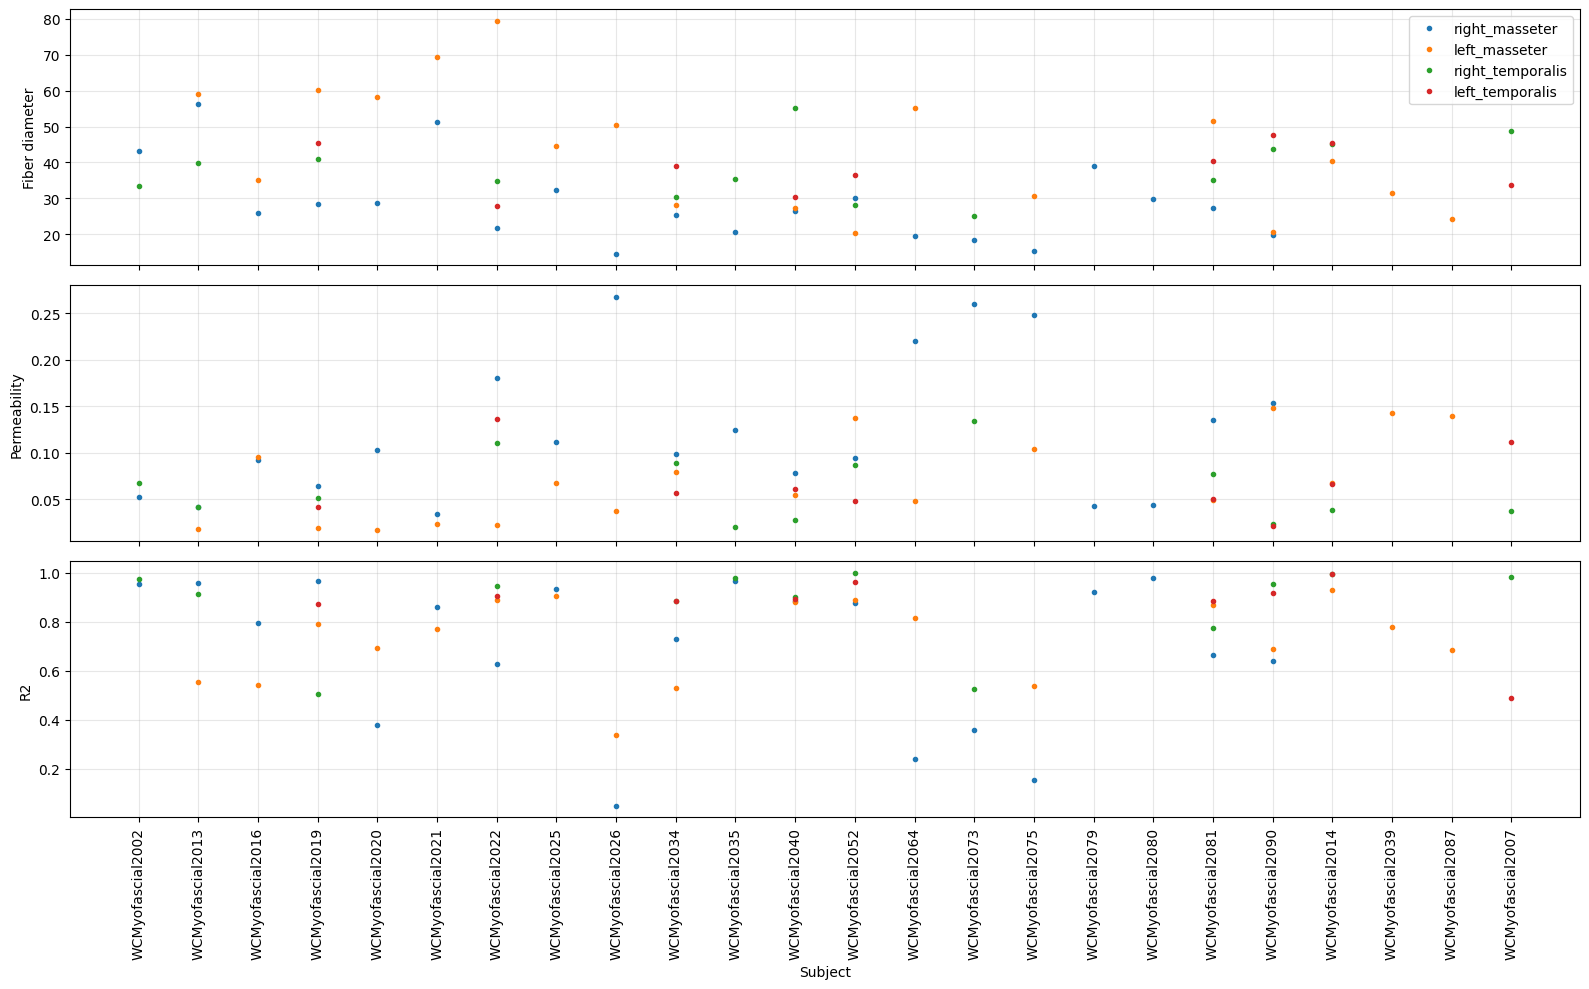

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

results_csv = '/Users/gabriellebaxter/Documents/HEAL_Volunteers/cornell/combined_results_triggerpoints.csv'
df = pd.read_csv(results_csv)

roi_names = ["right_masseter","left_masseter","right_temporalis","left_temporalis"]
params = ['a','kappa','R2']
ylabels = {'a':'Fiber diameter','kappa':'Permeability','R2':'R2'}

fig, axes = plt.subplots(3,1,figsize=(16,10),sharex=True)

for ax, param in zip(axes, params):
    for roi_name in roi_names:
        subset = df[df['ROI'] == roi_name]
        ax.plot(subset['Subject'].values, subset[param].values, '.', label=roi_name)
    ax.set_ylabel(ylabels[param])
    ax.grid(True, alpha=0.3)

axes[0].legend()
axes[-1].set_xlabel('Subject')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

['RD_median_0022ms', 'AD_median_0022ms', 'FA_median_0022ms', 'RD_median_0042ms', 'AD_median_0042ms', 'FA_median_0042ms', 'RD_median_0081ms', 'AD_median_0081ms', 'FA_median_0081ms', 'RD_median_0156ms', 'AD_median_0156ms', 'FA_median_0156ms', 'RD_median_0300ms', 'AD_median_0300ms', 'FA_median_0300ms']


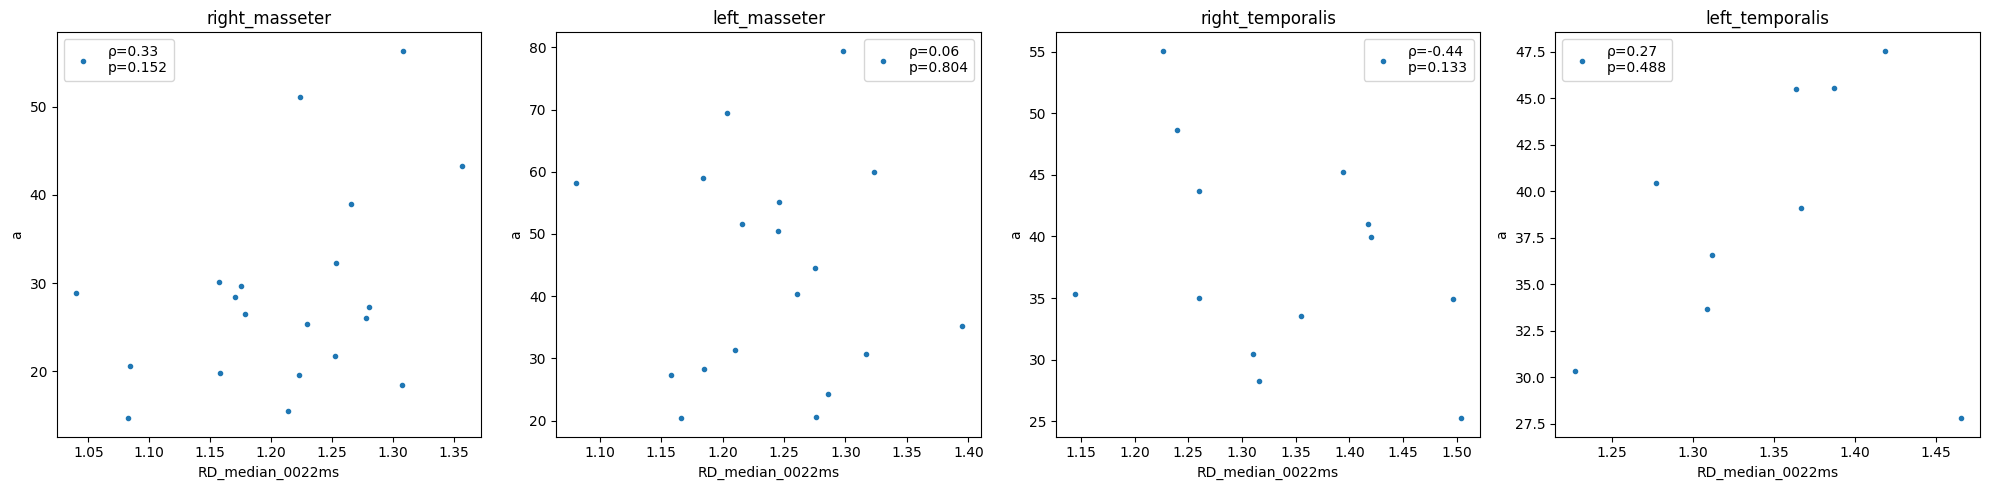

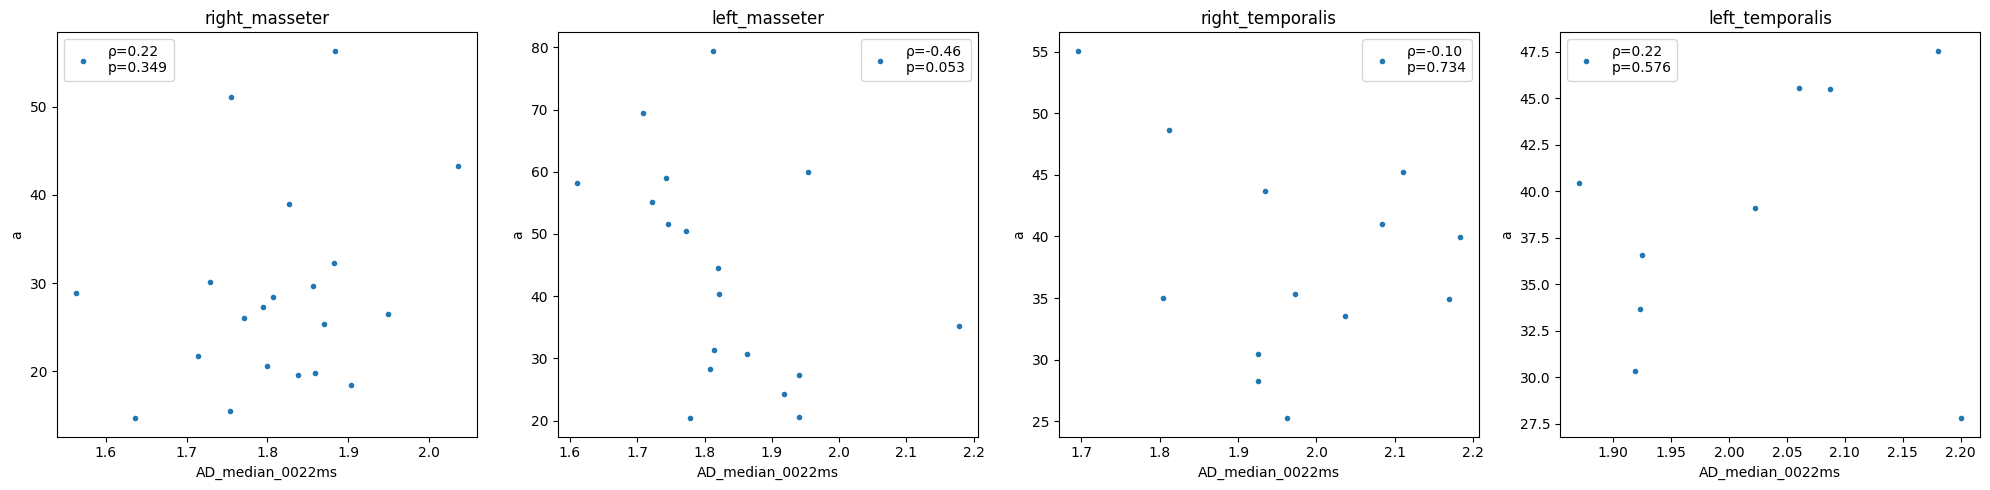

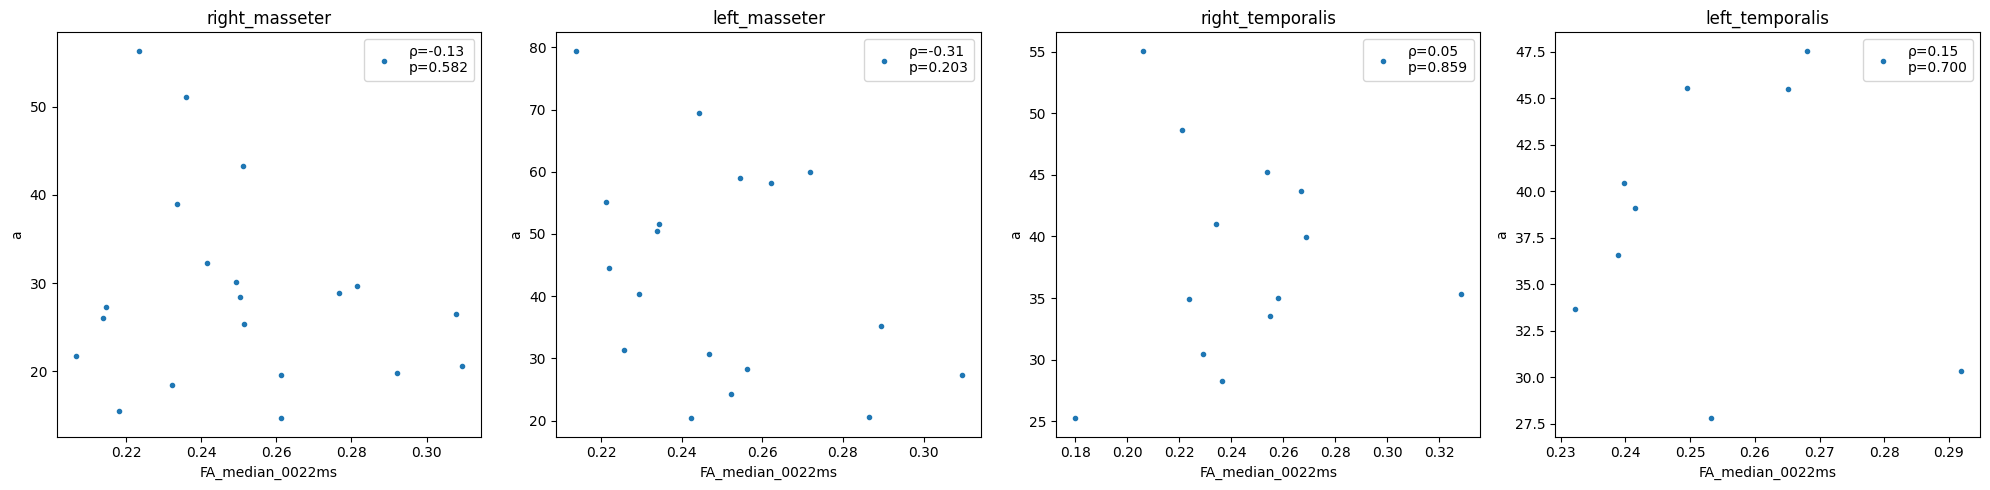

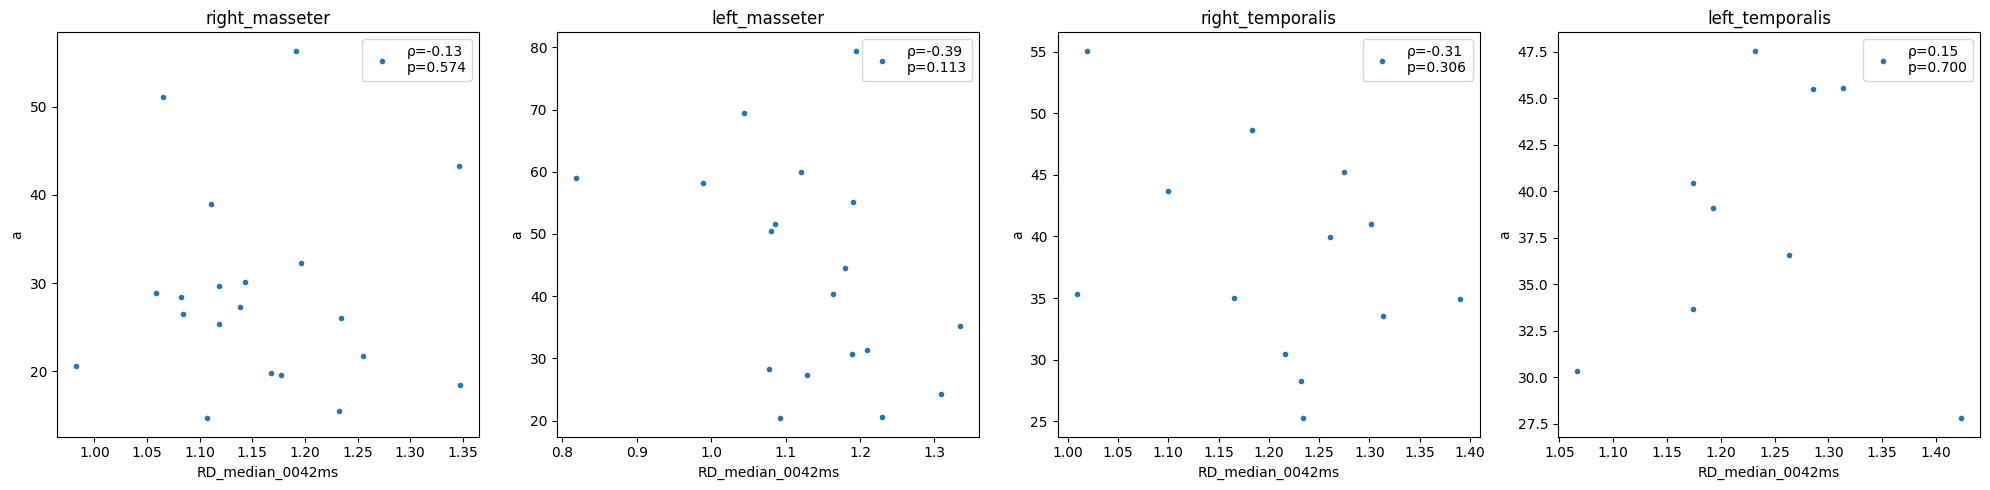

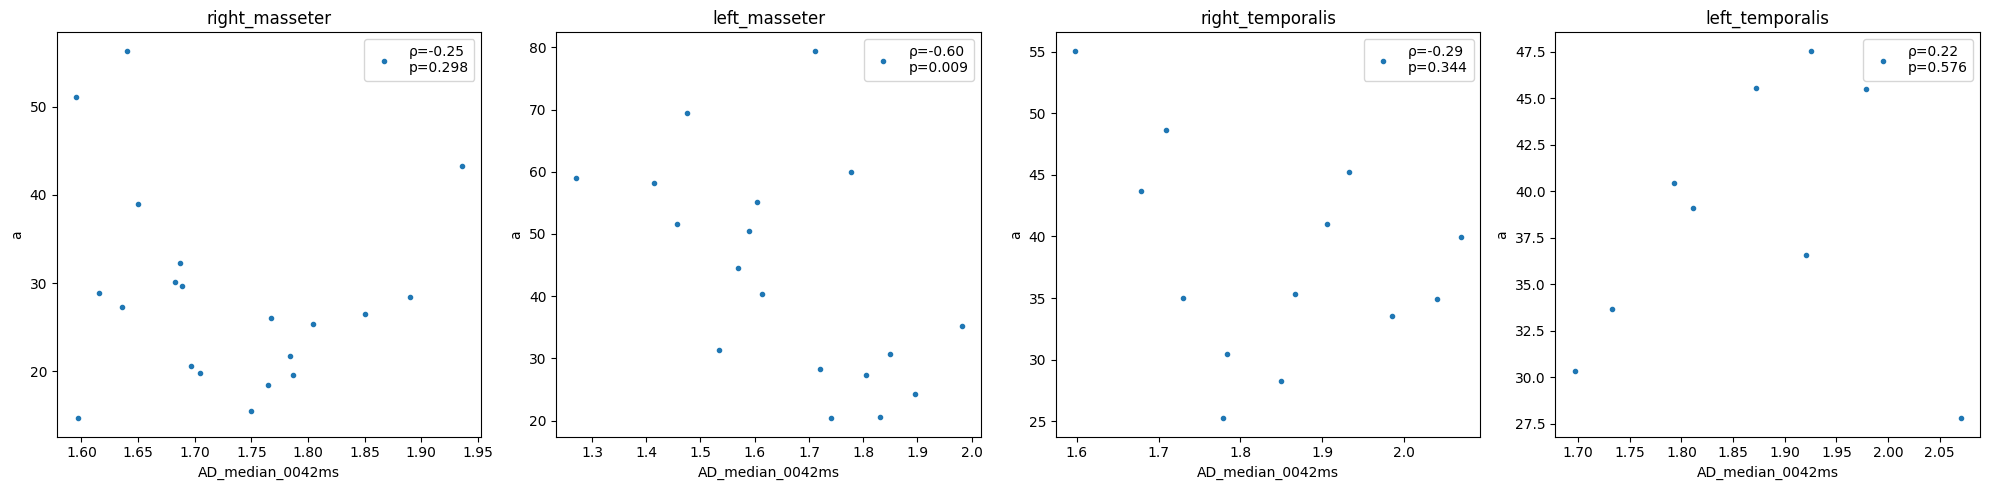

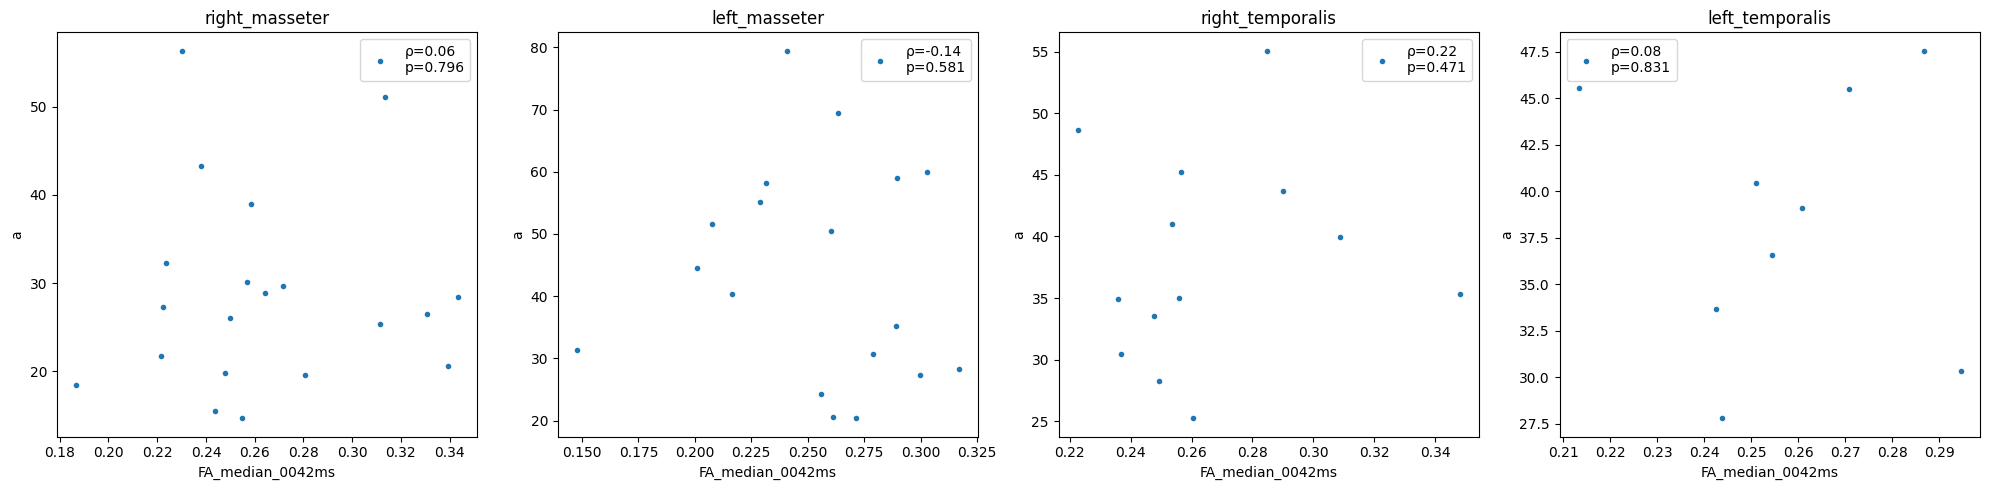

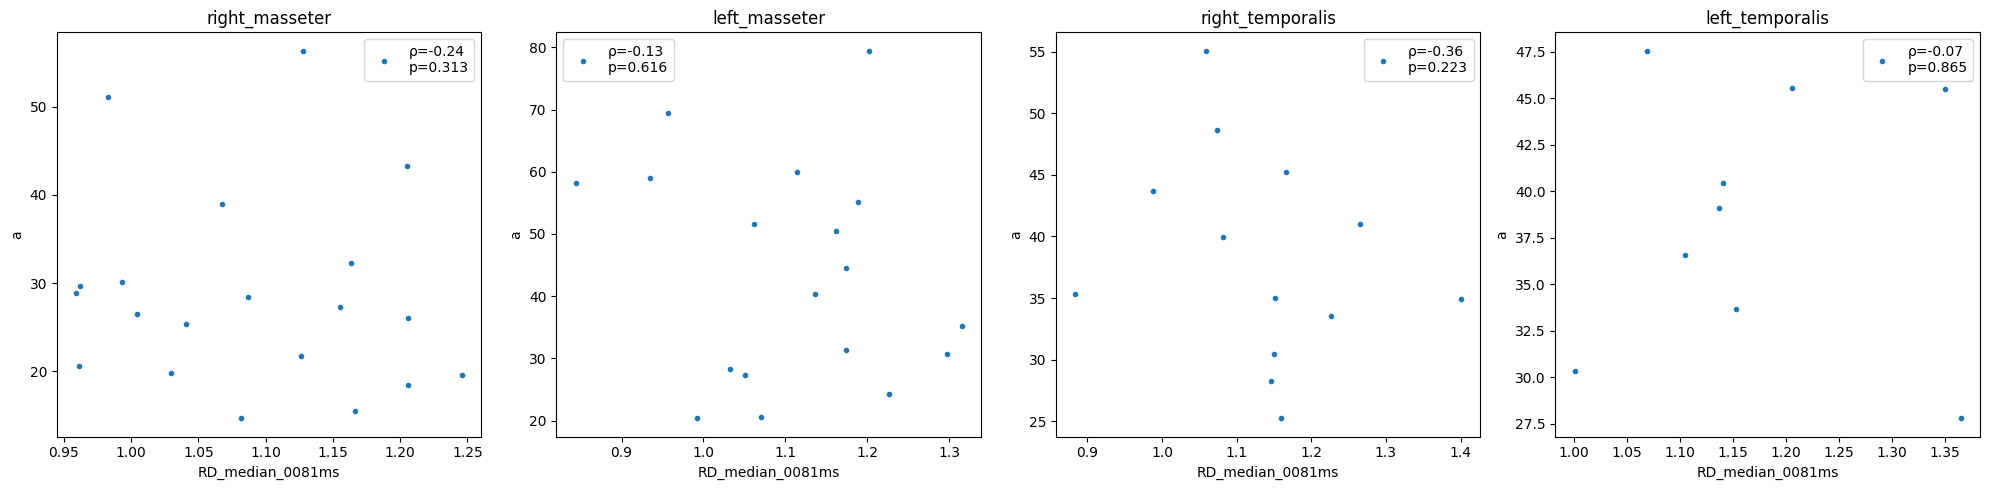

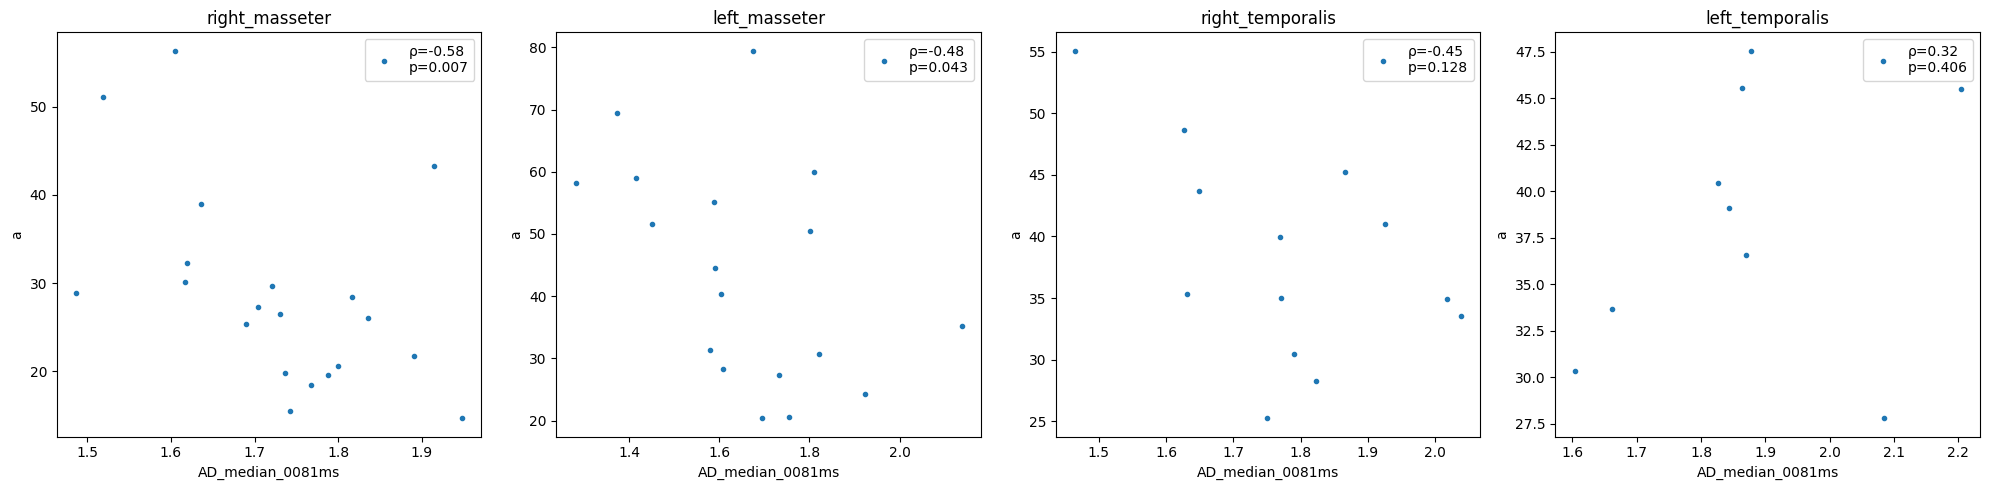

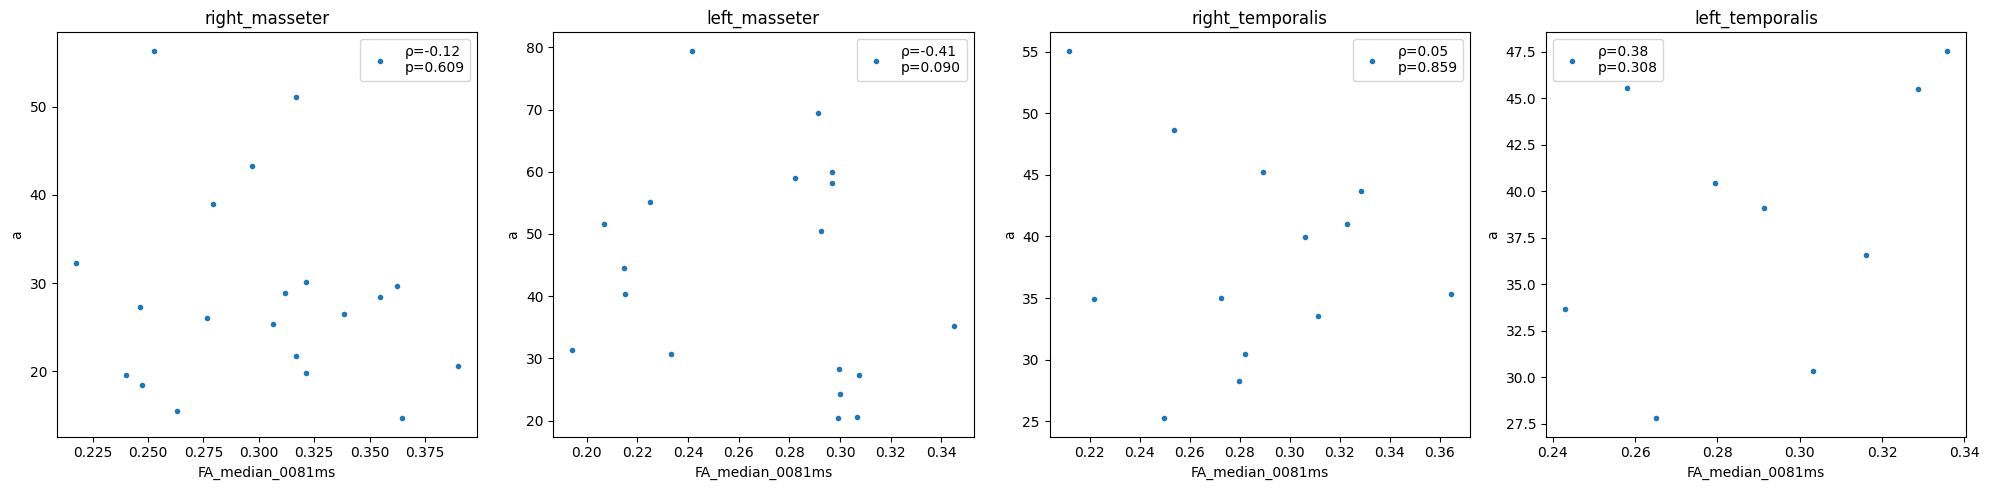

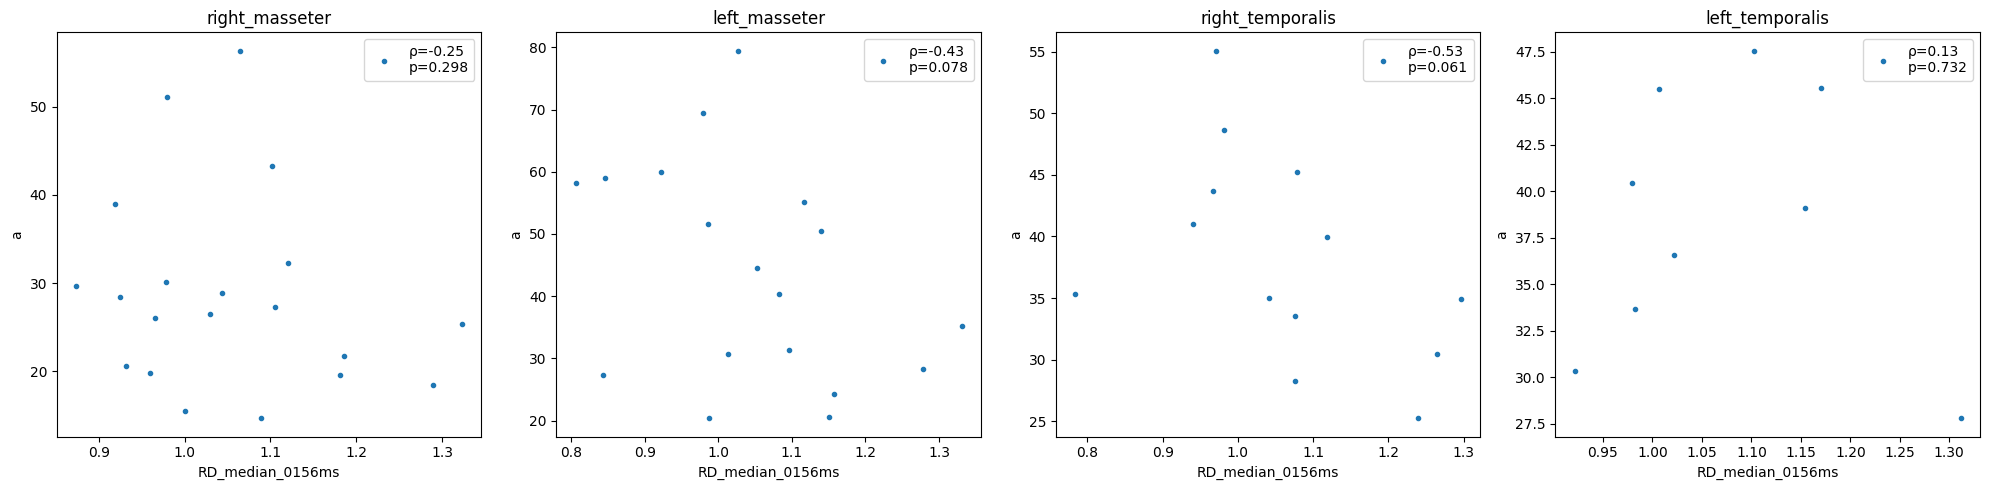

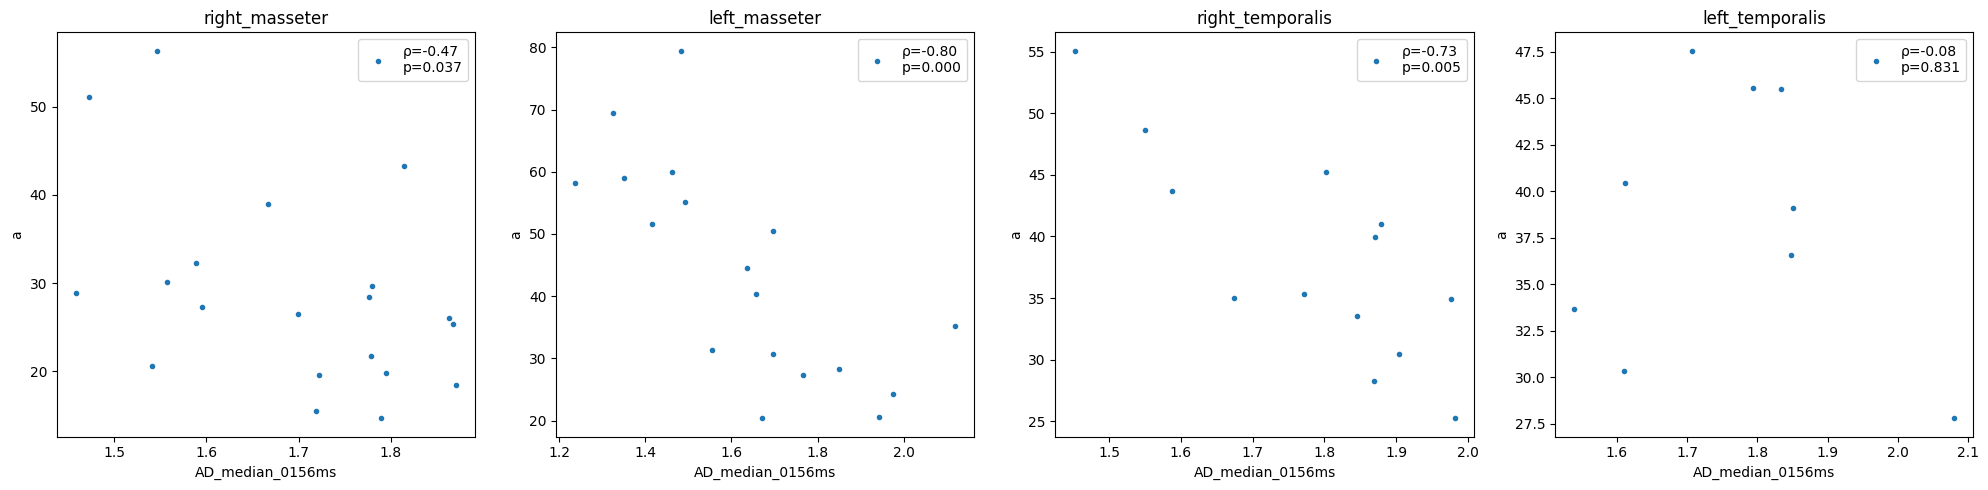

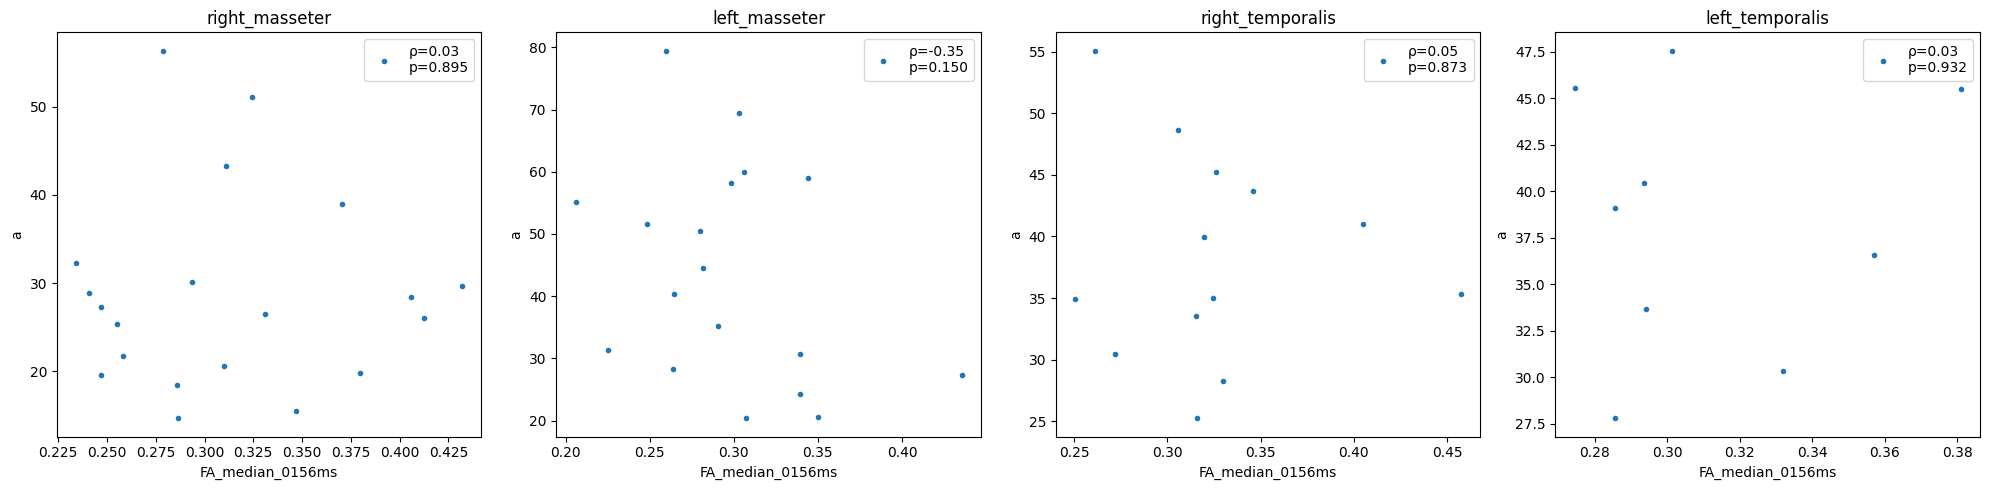

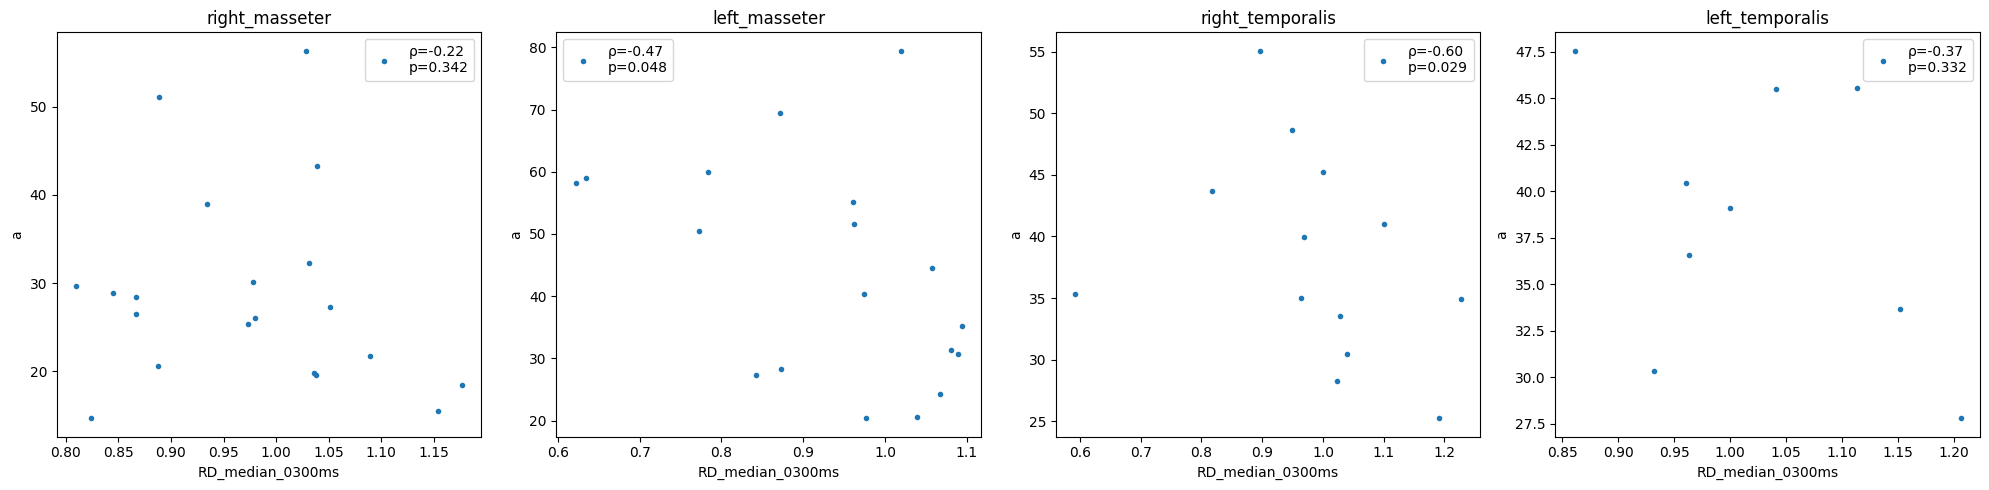

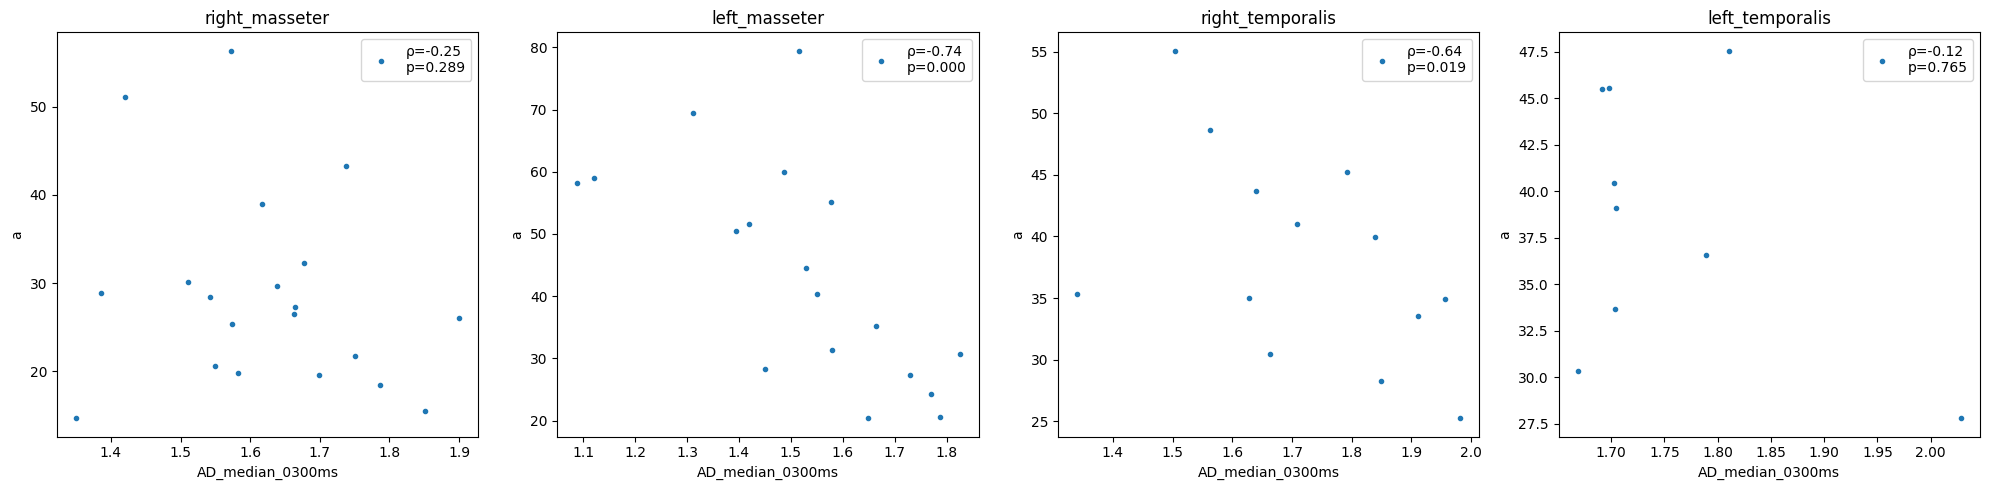

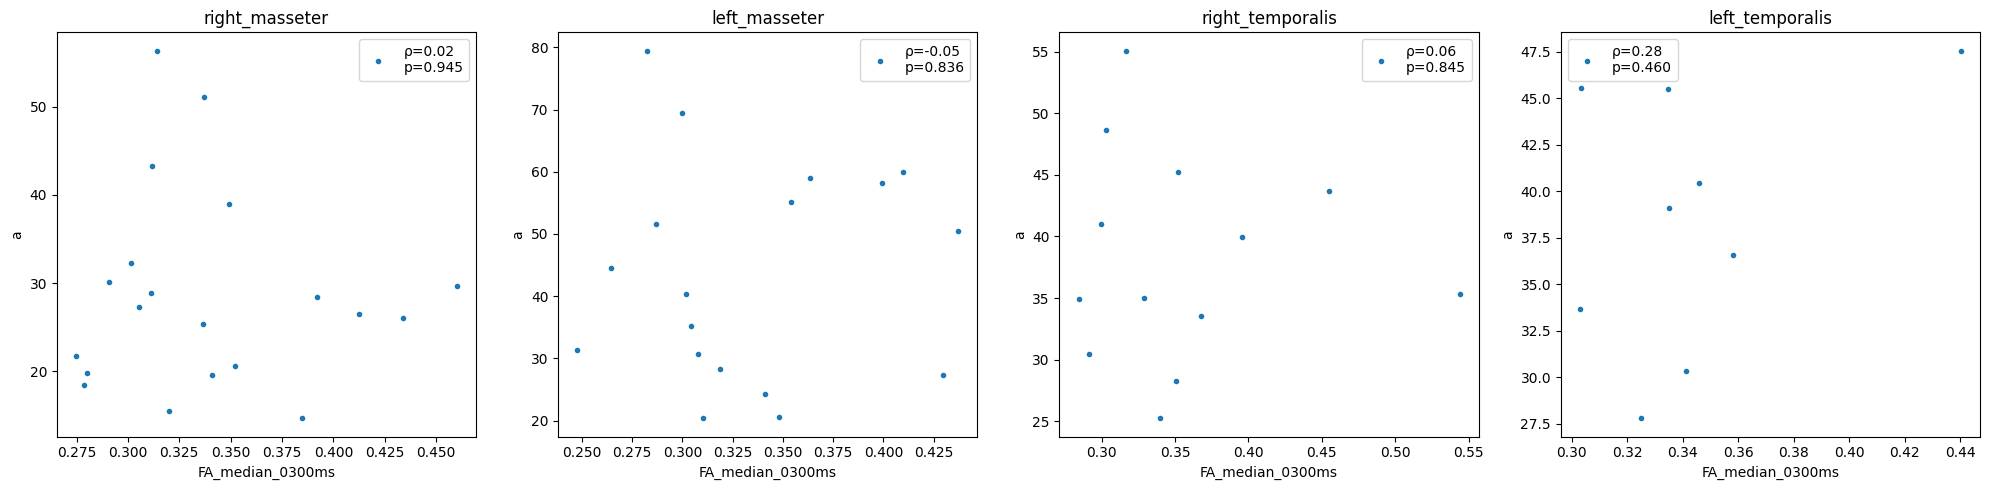

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

results_csv = '/Users/gabriellebaxter/Documents/HEAL_Volunteers/cornell/combined_results_triggerpoints.csv'
df = pd.read_csv(results_csv)

diffusion_times = ['0022ms','0042ms','0081ms','0156ms','0300ms']
variables = [s for s in df.columns if 'median' in s]
print(variables)

param = 'a'

for var in variables:
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False)
    for i, roi_name in enumerate(roi_names):
        temp_df = df[df['ROI'] == roi_name]

        x = temp_df[var].values
        y = temp_df[param].values

        # drop NaNs just in case
        mask = np.isfinite(x) & np.isfinite(y)
        x = x[mask]
        y = y[mask]

        if len(x) > 1:
            r, p = spearmanr(x, y)
        else:
            r = np.nan

        axes[i].plot(x, y, '.', label=f'ρ={r:.2f}\np={p:.3f}')

        axes[i].set_xlabel(var)
        axes[i].set_ylabel(param)
        axes[i].set_title(roi_name)
        axes[i].legend()

    plt.tight_layout()
    plt.show()